# 08: Now Prove It

An executable method workbench: tempting observations become measurements, controls, and bounded claims.


In [1]:
from pathlib import Path
import base64
import copy
import math
import sqlite3
from collections import Counter, defaultdict, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
def life_step(state):
    neighbors = (
        np.roll(np.roll(state, 1, axis=0), 1, axis=1)
        + np.roll(state, 1, axis=0)
        + np.roll(np.roll(state, 1, axis=0), -1, axis=1)
        + np.roll(state, 1, axis=1)
        + np.roll(state, -1, axis=1)
        + np.roll(np.roll(state, -1, axis=0), 1, axis=1)
        + np.roll(state, -1, axis=0)
        + np.roll(np.roll(state, -1, axis=0), -1, axis=1)
    )
    return (((state == 0) & (neighbors == 3)) | ((state == 1) & ((neighbors == 2) | (neighbors == 3)))).astype(np.uint8)

def run_life(state, generations):
    state = state.copy()
    history = [state.copy()]
    for _ in range(generations - 1):
        state = life_step(state)
        history.append(state.copy())
    return np.asarray(history)

GLIDER = np.array([[0,1,0],[0,0,1],[1,1,1]], dtype=np.uint8)

def empty_world(n):
    return np.zeros((n, n), dtype=np.uint8)

def place(world, pattern, row, col):
    world[row:row+pattern.shape[0], col:col+pattern.shape[1]] = pattern

def centroid(state):
    pos = np.argwhere(state == 1)
    return None if len(pos) == 0 else pos.mean(axis=0)


In [3]:
EXPERIMENT = {"glider_world": 40, "glider_generations": 20, "rule30_width": 201, "rule30_generations": 90}
EXPERIMENT


{'glider_world': 40,
 'glider_generations': 20,
 'rule30_width': 201,
 'rule30_generations': 90}

## Observation -> measurement: 'it moved'


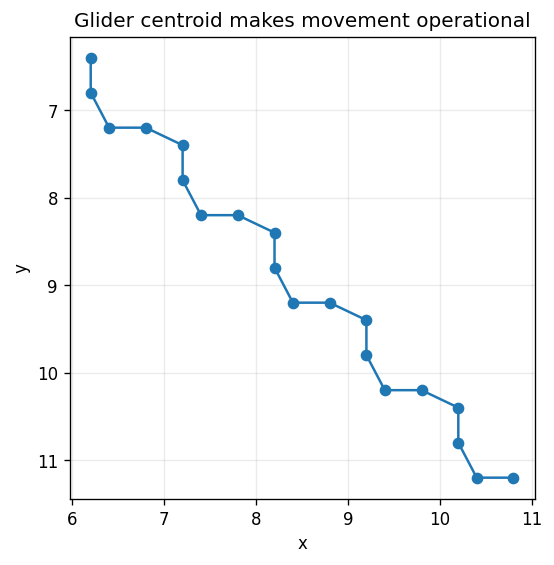

{'t0': [6.4, 6.2], 't4': [7.4, 7.2], 'displacement_t0_to_t4': [1.0, 1.0]}

In [4]:
world = empty_world(EXPERIMENT["glider_world"]); place(world, GLIDER, 5, 5); h = run_life(world, EXPERIMENT["glider_generations"])
pts = np.array([centroid(s) for s in h])
fig, ax = plt.subplots(figsize=(5,5)); ax.plot(pts[:,1], pts[:,0], marker="o"); ax.invert_yaxis(); ax.set(title="Glider centroid makes movement operational", xlabel="x", ylabel="y"); ax.grid(alpha=.25); plt.show()
{"t0": pts[0].tolist(), "t4": pts[4].tolist(), "displacement_t0_to_t4": (pts[4]-pts[0]).tolist()}


## Observation -> intervention -> narrowed claim: 'it regenerated'


In [5]:
def delete_first_active(state):
    out = state.copy(); pos = np.argwhere(out == 1); out[tuple(pos[0])] = 0; return out
intact = h; damaged = run_life(delete_first_active(world), EXPERIMENT["glider_generations"])
active = [(int(intact[t].sum()), int(damaged[t].sum())) for t in [0,1,4,8,16,19]]
active


[(5, 4), (5, 4), (5, 6), (5, 6), (5, 6), (5, 6)]

The damaged run can retain activity, but that is not recovery of the glider criterion.


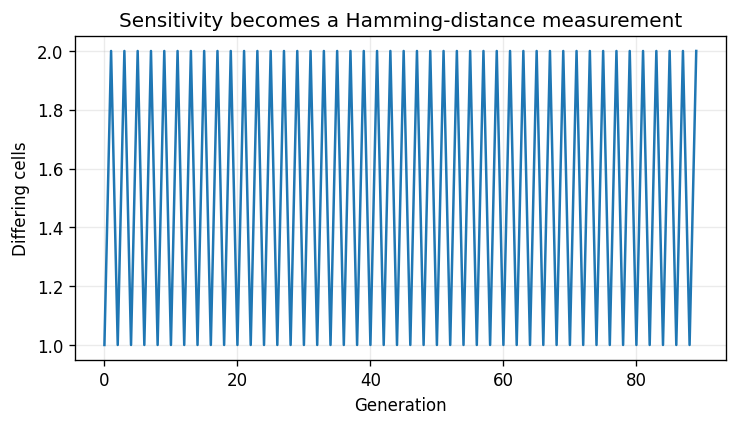

{'initial_difference': 1, 'max_difference': 2, 'final_difference': 2}

In [6]:
def eca_step(state, rule):
    return ((rule >> ((np.roll(state,1)<<2) | (state<<1) | np.roll(state,-1))) & 1).astype(np.uint8)
def run_rule(rule, width, generations, perturb=False):
    s=np.zeros(width,dtype=np.uint8); s[width//2]=1
    if perturb: s[width//2+1]=1
    hist=[]
    for _ in range(generations): hist.append(s.copy()); s=eca_step(s,rule)
    return np.asarray(hist)
a=run_rule(30, EXPERIMENT["rule30_width"], EXPERIMENT["rule30_generations"]); b=run_rule(30, EXPERIMENT["rule30_width"], EXPERIMENT["rule30_generations"], True); diff=(a!=b).sum(axis=1)
fig, ax=plt.subplots(figsize=(7,3.5)); ax.plot(diff); ax.set(title="Sensitivity becomes a Hamming-distance measurement", xlabel="Generation", ylabel="Differing cells"); ax.grid(alpha=.25); plt.show()
{"initial_difference": int(diff[0]), "max_difference": int(diff.max()), "final_difference": int(diff[-1])}


## Bounded conclusion

The notebook demonstrates the evidence ladder. Movement becomes centroid displacement under an identity criterion; damage response becomes a survival/recovery distinction; sensitivity becomes a difference field. It does not introduce a new empirical system.

## Provenance

**Book chapter**: `content/books/digital-life/08-now-prove-it/index.md`

**Research scripts used**: `ch03_the_first_surprise.py`, `ch04_pattern_becomes_a_thing.py`, `ch05_kill_it.py`

**Figures reproduced**: methodological inline figures only.
